# Preprocessing A1 v2 — Augmentasi AGRESIF untuk Kelas Electronic

**Versi:** v2 (agresif) — menggantikan v1 yang terlalu mirip aslinya  
**Strategi Crop:** Cara 2 kontinu, lebih agresif: skor=1 → scale (0.30, 0.65)  
**Output:** ~8,000 gambar Electronic di `Preprocessing_Data/augmented_electronic/`

---
**Perbedaan v2 vs v1:**
| Augmentasi | v1 | v2 |
|---|---|---|
| Crop scale (full_frame) | (0.50, 0.80) | **(0.30, 0.65)** |
| Aspect ratio | 0.75-1.33 | **0.67-1.50** |
| Brightness | +-30% | **+-60%** |
| Contrast | +-25% | **+-55%** |
| Saturation | +-25% | **+-60%** |
| Rotasi | +-15 deg | **+-30 deg** |
| Vertical Flip | - | **25%** |
| Perspective Warp | - | **40%** |
| Random Grayscale | - | **12%** |
| Gaussian Noise | - | **25%** |
| Cutout (1-2 blok) | - | **30%** |
| Hue shift | - | **8%** |

In [12]:
# CELL 1 - Setup & Import
import os, math, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageEnhance, ImageFilter, ImageOps, ImageDraw

try:
    import ipywidgets
    from tqdm.notebook import tqdm
    print('tqdm mode: notebook')
except ImportError:
    from tqdm import tqdm
    print('tqdm mode: text (ipywidgets tidak tersedia)')

import warnings
warnings.filterwarnings('ignore')
print('Import selesai')

tqdm mode: text (ipywidgets tidak tersedia)
Import selesai


In [13]:
# CELL 2 - Konfigurasi
ROOT           = Path(r"d:\Bagas\Satria_Data_BDC\BDC 2026")
TRAIN_DIR      = ROOT / "train"
EDA_DIR        = ROOT / "EDA"
PREPROC_DIR    = ROOT / "Preprocessing_Data"

ELECTRONIC_DIR = TRAIN_DIR / "1_Electronic"
OUTPUT_DIR     = PREPROC_DIR / "augmented_electronic"
CSV_FULL_FRAME = EDA_DIR / "eda_deteksi_full_frame.csv"

TARGET_TOTAL   = 8_000
IMG_SIZE       = 224
SEED           = 42
OVERWRITE      = True   # set False jika tidak mau hapus augmented lama

random.seed(SEED)
np.random.seed(SEED)

if OVERWRITE and OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
    print(f'Folder lama dihapus: {OUTPUT_DIR}')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Output dir   : {OUTPUT_DIR}')
print(f'Target total : {TARGET_TOTAL:,} gambar Electronic')
print(f'Output size  : {IMG_SIZE}x{IMG_SIZE} px')

Output dir   : d:\Bagas\Satria_Data_BDC\BDC 2026\Preprocessing_Data\augmented_electronic
Target total : 8,000 gambar Electronic
Output size  : 224x224 px


In [14]:
# CELL 3 - Load EDA Scores
df_eda = pd.read_csv(CSV_FULL_FRAME)
df_elec = df_eda[df_eda['label'] == 'Electronic'][['nama_file', 'skor_akhir']].dropna()
score_map = dict(zip(df_elec['nama_file'], df_elec['skor_akhir']))

existing_files = [f for f in ELECTRONIC_DIR.glob('*')
                  if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]

FALLBACK_SCORE = df_elec['skor_akhir'].median()
file_scores = [(f, score_map.get(f.name, FALLBACK_SCORE)) for f in existing_files]

scores_all = [s for _, s in file_scores]
n_full = sum(1 for s in scores_all if s >= 0.65)
n_mid  = sum(1 for s in scores_all if 0.35 <= s < 0.65)
n_bg   = sum(1 for s in scores_all if s < 0.35)

print(f'Total Electronic di disk     : {len(existing_files):,}')
print(f'Match EDA                    : {sum(1 for f,_ in file_scores if f.name in score_map):,}')
print(f'Fallback ke median ({FALLBACK_SCORE:.3f})     : {sum(1 for f,_ in file_scores if f.name not in score_map):,}')
print(f'Distribusi zona skor:')
print(f'  full_frame (>=0.65)        : {n_full:,} ({100*n_full/len(scores_all):.1f}%)')
print(f'  perlu_cek_manual (0.35-0.65): {n_mid:,} ({100*n_mid/len(scores_all):.1f}%)')
print(f'  background_terpisah (<0.35): {n_bg:,} ({100*n_bg/len(scores_all):.1f}%)')

Total Electronic di disk     : 3,961
Match EDA                    : 3,958
Fallback ke median (0.638)     : 3
Distribusi zona skor:
  full_frame (>=0.65)        : 1,909 (48.2%)
  perlu_cek_manual (0.35-0.65): 1,243 (31.4%)
  background_terpisah (<0.35): 809 (20.4%)


In [15]:
# CELL 4 - Fungsi Augmentasi AGRESIF v2

def lerp(a, b, t):
    return a + (b - a) * float(np.clip(t, 0.0, 1.0))

def get_crop_scale_v2(skor):
    """
    v2 - lebih agresif:
    - skor=0 (background): scale=(0.75, 0.95)
    - skor=1 (full_frame): scale=(0.30, 0.65)  <- agresif!
    """
    scale_min = lerp(0.75, 0.30, skor)
    scale_max = lerp(0.95, 0.65, skor)
    return (round(scale_min, 4), round(scale_max, 4))

def random_resized_crop(img, scale, ratio=(0.67, 1.50)):
    """Aspect ratio lebih lebar dari v1 (0.67-1.50)."""
    w, h = img.size
    area = w * h
    for _ in range(12):
        ta = random.uniform(scale[0], scale[1]) * area
        ar = random.uniform(ratio[0], ratio[1])
        nw = int(round(math.sqrt(ta * ar)))
        nh = int(round(math.sqrt(ta / ar)))
        if 0 < nw <= w and 0 < nh <= h:
            x = random.randint(0, w - nw)
            y = random.randint(0, h - nh)
            return img.crop((x, y, x+nw, y+nh))
    side = min(w, h)
    return img.crop(((w-side)//2, (h-side)//2, (w+side)//2, (h+side)//2))

def _find_perspective_coeffs(pa, pb):
    matrix = []
    for p1, p2 in zip(pa, pb):
        matrix.append([p1[0], p1[1], 1, 0, 0, 0, -p2[0]*p1[0], -p2[0]*p1[1]])
        matrix.append([0, 0, 0, p1[0], p1[1], 1, -p2[1]*p1[0], -p2[1]*p1[1]])
    A = np.matrix(matrix, dtype=np.float64)
    B = np.array(pb).reshape(8)
    return np.linalg.solve(A, B).flatten().tolist()

def perspective_warp(img, magnitude=0.20):
    """Perspective warp acak hingga magnitude*lebar bergeser."""
    w, h = img.size
    mx = int(magnitude * w)
    my = int(magnitude * h)
    rw = lambda: random.randint(-mx, mx)
    rh = lambda: random.randint(-my, my)
    src = [(0,0),(w,0),(w,h),(0,h)]
    dst = [(rw(),rh()),(w+rw(),rh()),(w+rw(),h+rh()),(rw(),h+rh())]
    try:
        coeffs = _find_perspective_coeffs(src, dst)
        return img.transform(img.size, Image.PERSPECTIVE, coeffs, Image.BILINEAR)
    except Exception:
        return img

def random_cutout(img, n_holes=1, min_frac=0.08, max_frac=0.22):
    """Cutout: blok piksel diganti abu-abu. Paksa model belajar parsial."""
    img = img.copy()
    draw = ImageDraw.Draw(img)
    w, h = img.size
    for _ in range(n_holes):
        cw = int(random.uniform(min_frac, max_frac) * w)
        ch = int(random.uniform(min_frac, max_frac) * h)
        x = random.randint(0, w - cw)
        y = random.randint(0, h - ch)
        draw.rectangle([x, y, x+cw, y+ch], fill=(115, 115, 115))
    return img

def add_gaussian_noise(img, std=0.05):
    """Gaussian noise untuk simulasi gambar berkualitas rendah."""
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = np.clip(arr + np.random.normal(0, std, arr.shape), 0, 1)
    return Image.fromarray((arr * 255).astype(np.uint8))

def augment_image_v2(img_path, skor, aug_idx=0):
    """Pipeline augmentasi AGRESIF v2."""
    seed_val = (SEED + aug_idx * 1000 + hash(img_path.name) % 100000) % (2**31)
    random.seed(seed_val)
    np.random.seed(seed_val)

    img = Image.open(img_path).convert('RGB')

    # 1. Adaptive Crop AGRESIF v2
    img = random_resized_crop(img, scale=get_crop_scale_v2(skor))
    # 2. Resize
    img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    # 3. Horizontal Flip (50%)
    if random.random() < 0.50: img = ImageOps.mirror(img)
    # 4. Vertical Flip (25%)
    if random.random() < 0.25: img = ImageOps.flip(img)
    # 5. Perspective Warp (40%)
    if random.random() < 0.40: img = perspective_warp(img, magnitude=random.uniform(0.12, 0.22))
    # 6. Rotasi +-30 deg (50%)
    if random.random() < 0.50: img = img.rotate(random.uniform(-30, 30), resample=Image.BILINEAR, expand=False)
    # 7. Color Jitter EKSTREM
    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.40, 1.60))
    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.45, 1.55))
    img = ImageEnhance.Color(img).enhance(random.uniform(0.40, 1.60))
    # 8. Random Grayscale (12%)
    if random.random() < 0.12: img = ImageOps.grayscale(img).convert('RGB')
    # 9. Hue shift channel swap (8%)
    if random.random() < 0.08:
        r, g, b = img.split()
        img = Image.merge('RGB', random.choice([(r,g,b),(g,r,b),(b,g,r),(r,b,g)]))
    # 10. Blur atau Sharpen
    rnd = random.random()
    if rnd < 0.20: img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.5, 2.0)))
    elif rnd < 0.40: img = ImageEnhance.Sharpness(img).enhance(random.uniform(1.5, 3.0))
    # 11. Gaussian Noise (25%)
    if random.random() < 0.25: img = add_gaussian_noise(img, std=random.uniform(0.02, 0.06))
    # 12. Cutout (30%)
    if random.random() < 0.30: img = random_cutout(img, n_holes=random.choice([1,2]))

    return img


# Sanity check crop scale
print('=== Sanity Check Crop Scale v2 ===')
for s in [0.0, 0.35, 0.50, 0.65, 1.0]:
    smin, smax = get_crop_scale_v2(s)
    zona = 'full_frame' if s >= 0.65 else ('perlu_cek' if s >= 0.35 else 'background')
    print(f'  skor={s:.2f} [{zona:>12s}] -> scale ({smin:.2f}, {smax:.2f})')
print('Fungsi augmentasi v2 siap')

=== Sanity Check Crop Scale v2 ===
  skor=0.00 [  background] -> scale (0.75, 0.95)
  skor=0.35 [   perlu_cek] -> scale (0.59, 0.84)
  skor=0.50 [   perlu_cek] -> scale (0.53, 0.80)
  skor=0.65 [  full_frame] -> scale (0.46, 0.76)
  skor=1.00 [  full_frame] -> scale (0.30, 0.65)
Fungsi augmentasi v2 siap


In [16]:
# CELL 5 - Pipeline Augmentasi
existing_count = len(existing_files)
needed = max(0, TARGET_TOTAL - existing_count)
aug_per_img = math.ceil(needed / existing_count)

print(f'Electronic existing  : {existing_count:,}')
print(f'Target total         : {TARGET_TOTAL:,}')
print(f'Perlu dibuat         : {needed:,}')
print(f'Augmentasi per gambar: ~{aug_per_img}x')
print()

generated = 0
failed    = 0
skor_log  = []

with tqdm(total=needed, desc='Augmentasi Electronic v2', unit='img') as pbar:
    random.shuffle(file_scores)
    for aug_idx in range(aug_per_img):
        for img_path, skor in file_scores:
            if generated >= needed:
                break
            try:
                aug_img = augment_image_v2(img_path, skor, aug_idx=aug_idx)
                out_name = f"aug_{generated:05d}_{img_path.stem}.jpg"
                aug_img.save(OUTPUT_DIR / out_name, 'JPEG', quality=90)
                skor_log.append(skor)
                generated += 1
                pbar.update(1)
            except Exception:
                failed += 1
        if generated >= needed:
            break

print(f'Generated : {generated:,}')
if failed: print(f'Gagal     : {failed:,}')
print(f'Total Electronic: {existing_count + generated:,}')

Electronic existing  : 3,961
Target total         : 8,000
Perlu dibuat         : 4,039
Augmentasi per gambar: ~2x



Augmentasi Electronic v2: 100%|██████████| 4039/4039 [01:02<00:00, 64.66img/s]

Generated : 4,039
Gagal     : 3
Total Electronic: 8,000


DISTRIBUSI KELAS SETELAH AUGMENTASI v2
Recyclable  :  9,999  ( 32.7%)
Electronic  :  8,000  ( 26.2%)
Organic     : 12,567  ( 41.1%)
TOTAL       : 30,566

Diversity check:
  Original  : mean=0.522, std=0.185
  Augmented : mean=0.415, std=0.197
  Diversity ratio: 1.067x (target >1.20)


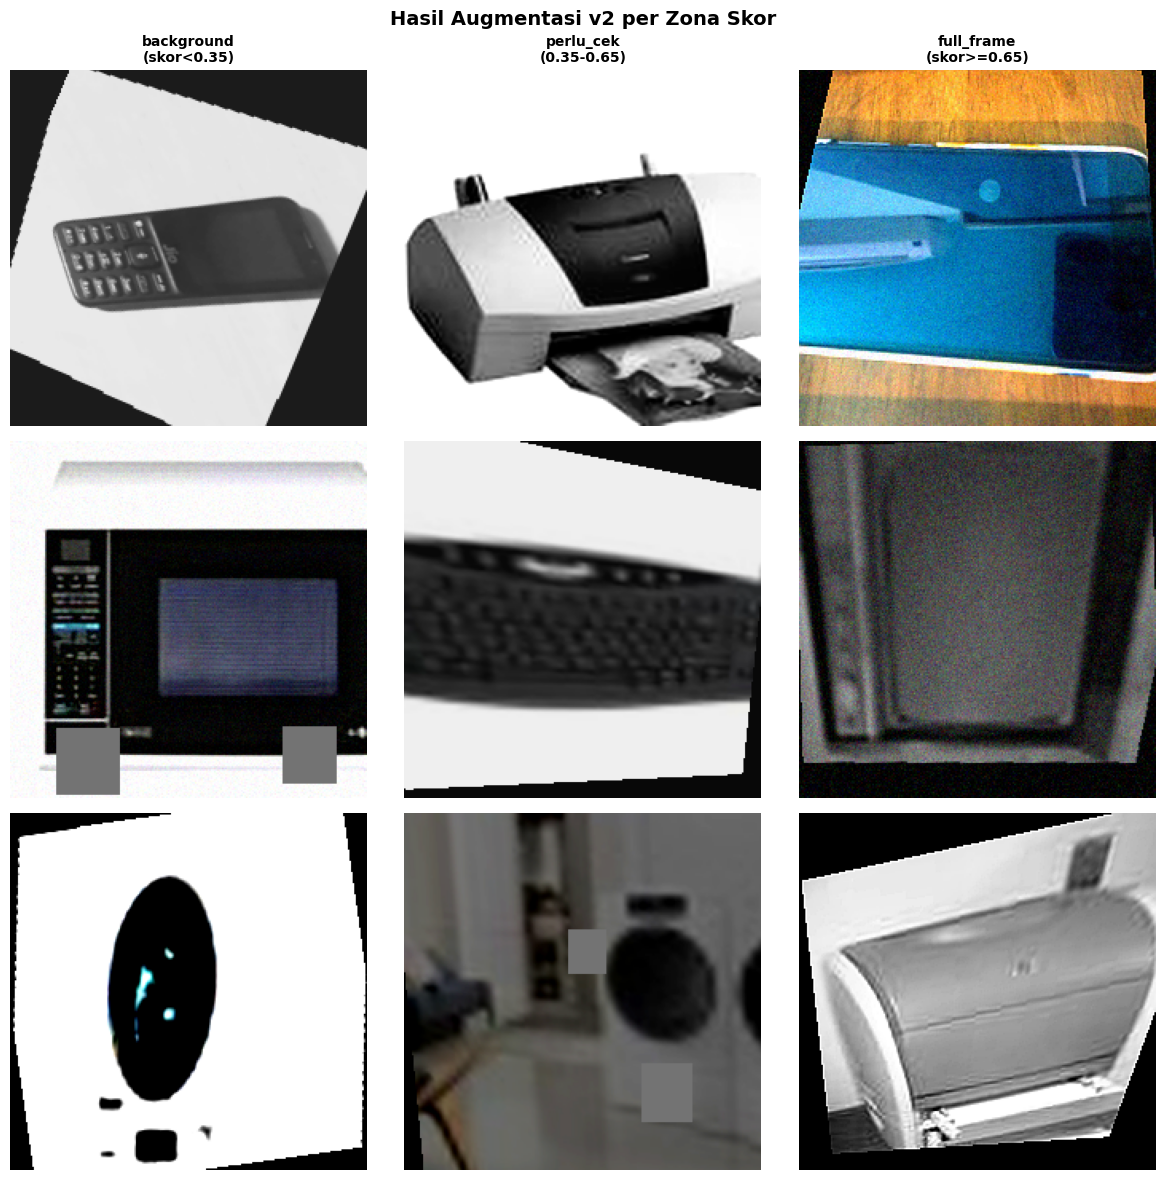

Grid sample disimpan: d:\Bagas\Satria_Data_BDC\BDC 2026\Preprocessing_Data\augmentation_v2_grid.png

Preprocessing A1 v2 selesai!


In [17]:
# CELL 6 - Verifikasi & Visualisasi
import random as rnd

# Distribusi kelas akhir
count_recyclable = len(list((TRAIN_DIR / '0_Recyclable').glob('*.jpg')))
count_electronic = len(existing_files) + len(list(OUTPUT_DIR.glob('*.jpg')))
count_organic    = len(list((TRAIN_DIR / '2_Organic').glob('*.jpg')))
total = count_recyclable + count_electronic + count_organic

print('DISTRIBUSI KELAS SETELAH AUGMENTASI v2')
print('=' * 45)
for name, count in [('Recyclable', count_recyclable), ('Electronic', count_electronic), ('Organic', count_organic)]:
    pct = 100 * count / total
    print(f'{name:12s}: {count:6,}  ({pct:5.1f}%)')
print(f'{"TOTAL":12s}: {total:6,}')

# Diversity check
def mean_brightness(files, n=200):
    sample = rnd.sample(files, min(n, len(files)))
    vals = []
    for f in sample:
        try:
            arr = np.array(Image.open(f).convert('RGB').resize((32,32)), dtype=np.float32)/255.0
            vals.append(arr.mean())
        except: pass
    return np.array(vals)

aug_files_all = list(OUTPUT_DIR.glob('*.jpg'))
b_orig = mean_brightness(existing_files)
b_aug  = mean_brightness(aug_files_all)

print(f'\nDiversity check:')
print(f'  Original  : mean={b_orig.mean():.3f}, std={b_orig.std():.3f}')
print(f'  Augmented : mean={b_aug.mean():.3f}, std={b_aug.std():.3f}')
print(f'  Diversity ratio: {b_aug.std()/b_orig.std():.3f}x (target >1.20)')

# Visual grid 3x3 dari zona berbeda
if len(aug_files_all) >= 9:
    zones = {
        'background\n(skor<0.35)':  [(f,s) for f,s in file_scores if s<0.35][:3],
        'perlu_cek\n(0.35-0.65)': [(f,s) for f,s in file_scores if 0.35<=s<0.65][:3],
        'full_frame\n(skor>=0.65)': [(f,s) for f,s in file_scores if s>=0.65][:3],
    }
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    fig.suptitle('Hasil Augmentasi v2 per Zona Skor', fontsize=14, fontweight='bold')
    for col_idx, (zone_name, samples) in enumerate(zones.items()):
        axes[0][col_idx].set_title(zone_name, fontsize=10, fontweight='bold')
        for row_idx, (src_path, skor) in enumerate(samples[:3]):
            try:
                result = augment_image_v2(src_path, skor, aug_idx=row_idx+20)
                axes[row_idx][col_idx].imshow(result)
                s = get_crop_scale_v2(skor)
                axes[row_idx][col_idx].set_xlabel(f'skor={skor:.3f}\nscale={s}', fontsize=7)
            except Exception:
                axes[row_idx][col_idx].text(0.5, 0.5, 'Error', ha='center', va='center')
            axes[row_idx][col_idx].axis('off')
    plt.tight_layout()
    plt.savefig(PREPROC_DIR / 'augmentation_v2_grid.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Grid sample disimpan:', PREPROC_DIR / 'augmentation_v2_grid.png')

print('\nPreprocessing A1 v2 selesai!')